In [201]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [202]:
plt.style.use('ggplot')

In [203]:
df = pd.read_csv('email.csv')

In [204]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [205]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [206]:
df.tail(1)

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [207]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [208]:
df = df.iloc[:-1]

In [209]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [210]:
df.shape

(5572, 2)

In [211]:
df.dtypes

Category    object
Message     object
dtype: object

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [213]:
df.isnull().sum().sum()

np.int64(0)

In [214]:
df.duplicated().sum() / df.shape[0]

np.float64(0.07447954055994258)

In [215]:
df.drop_duplicates(inplace=True)

In [216]:
df["Category"].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [217]:
df["Category"].value_counts(normalize=True) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

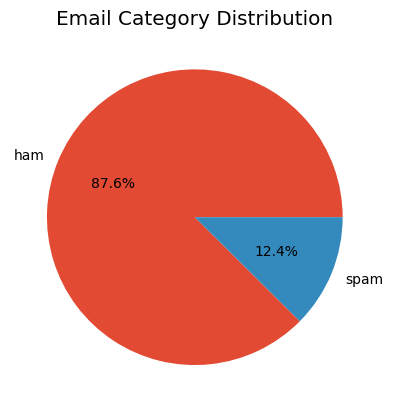

In [218]:
df["Category"].value_counts().plot(
    kind = "pie",
    autopct = "%1.1f%%"
)

plt.ylabel("")

plt.title("Email Category Distribution")

plt.show()

In [219]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [220]:
df["Message_Length"] = df["Message"].apply(len)

In [221]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [222]:
df["Message"][1]

'Ok lar... Joking wif u oni...'

In [223]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

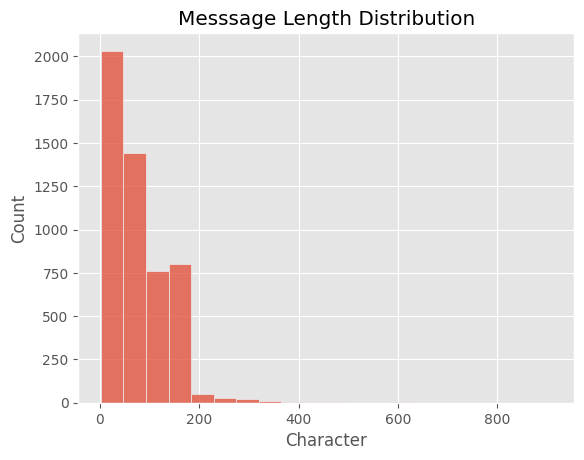

In [224]:
sns.histplot(df["Message_Length"], bins=20)

plt.title("Messsage Length Distribution")

plt.xlabel("Character")

plt.show()

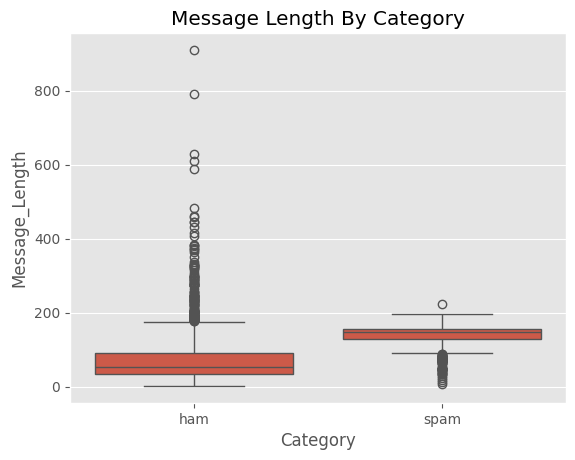

In [225]:
sns.boxplot(

    data = df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length By Category")

plt.show()

In [226]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

Text(0.5, 1.0, 'Average Message Length')

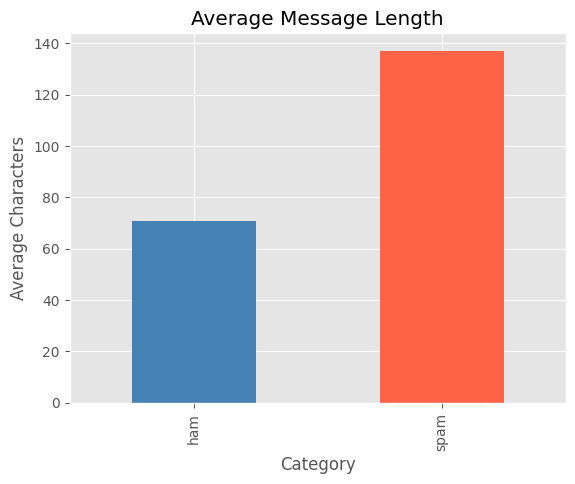

In [227]:
df.groupby("Category")["Message_Length"].mean().plot(

    kind = "bar",
    color = ["steelblue", "tomato"]
)

plt.ylabel("Average Characters")

plt.title("Average Message Length")

In [228]:
df["Word_Count"] = df["Message"].apply(lambda x : len(x.split()))

In [229]:
df.head()

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


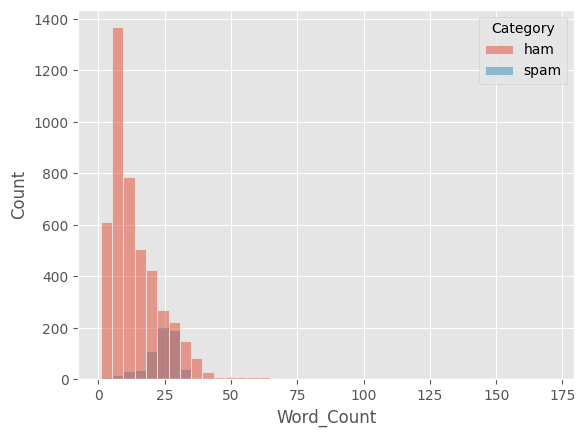

In [230]:
sns.histplot(

    data = df,
    x = "Word_Count",
    hue = "Category",
    bins = 40
)

plt.show()

In [231]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [232]:
df.nsmallest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [233]:
df.nlargest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [234]:
df[df["Category"] == "spam"].sample(5)

,Category,Message,Message_Length,Word_Count
4069,spam,TBS/PERSOLVO. been chasing us since Sept for£3...,140,21
4394,spam,RECPT 1/3. You have ordered a Ringtone. Your o...,72,12
4696,spam,URGENT! Your Mobile No 07808726822 was awarded...,154,25
3560,spam,URGENT! We are trying to contact U Todays draw...,156,27
1734,spam,"Hi, this is Mandy Sullivan calling from HOTMIX...",223,34


In [235]:
df[df["Category"] == "ham"].sample(5)

,Category,Message,Message_Length,Word_Count
316,ham,K.k:)advance happy pongal.,26,3
4030,ham,"[…] anyway, many good evenings to u! s",38,8
3836,ham,I'm thinking that chennai forgot to come for a...,54,9
3195,ham,And you! Will expect you whenever you text! Ho...,67,13
2718,ham,Okie.. Thanx..,14,2


In [236]:
df

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30
5568,ham,Will ü b going to esplanade fr home?,36,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


In [237]:
df["Category"] = df["Category"].map({

    "ham" : 0,
    "spam" : 1
})

In [238]:
df.head()

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [239]:
import warnings
warnings.filterwarnings("ignore")

In [240]:
from sklearn.model_selection import train_test_split

In [241]:
X = df["Message"]

In [242]:
y = df["Category"]

In [243]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y
)

In [244]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 5000,
    ngram_range = (1,2)
)

In [245]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [246]:
X_test_tfidf = tfidf.transform(X_test)

In [247]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV


In [250]:
models = {
    "Naive Bayes":(
        MultinomialNB(),
        {
            "alpha": [0.1, 0.5, 1, 2, 5]
        }
        
    ),

    "LogisticRegression":(
        LogisticRegression(
            class_weight = "balanced",
            max_iter = 1000
        ),
        {
            "C" : [0.01, 0.1, 1, 10, 100]
        }
    ),
    "Linear SVM": (
        LinearSVC(
            class_weight = "balanced"
        ),
        {
            "C" : [0.01, 0.1, 1, 10, 100]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(
            class_weight = "balanced"
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight = "balanced"
        ),
        {
            "max_depth" : [5, 10, 20, None],
            "min_samples_split" : [2, 5, 10]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(),
        {
            "n_estimators" : [100, 200],
            "learning_rate" : [0.01, 0.05, 0.1],
            "max_depth" : [3, 5]
        }
    ),
    "KNN" : (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 9]
        }
        
    )
}

In [252]:
result = [ ]

best_models = {}

for name,(model, params) in models.items():
    search = RandomizedSearchCV(
        estimator= model,
        param_distributions= params,
        n_iter= 10,
        cv = 5,
        scoring= "f1",
        n_jobs= -1

    )

    search.fit (X_train_tfidf, y_train)

    best_model = search.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    try:
        auc = roc_auc_score (y_test , best_model.decision_function(X_test_tfidf))
    except:
        try:
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf)
            )
        except:
            auc = np.nan

    result.append({
        "Model":name,
        "Accuracy": accuracy,
        "precision" : precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Best Params": search.best_params_

    })



In [253]:
result 

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9883720930232558,
  'precision': 0.9833333333333333,
  'Recall': 0.921875,
  'F1 Score': 0.9516129032258065,
  'ROC AUC': nan,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.9835271317829457,
  'precision': 0.9512195121951219,
  'Recall': 0.9140625,
  'F1 Score': 0.9322709163346613,
  'ROC AUC': 0.9946850801991151,
  'Best Params': {'C': 10}},
 {'Model': 'Linear SVM',
  'Accuracy': 0.9835271317829457,
  'precision': 0.9512195121951219,
  'Recall': 0.9140625,
  'F1 Score': 0.9322709163346613,
  'ROC AUC': 0.9948492809734514,
  'Best Params': {'C': 1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9815891472868217,
  'precision': 0.9739130434782609,
  'Recall': 0.875,
  'F1 Score': 0.9218106995884774,
  'ROC AUC': nan,
  'Best Params': {'n_estimators': 200,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9525193798449613,
  'precision': 0.7801418439716312,
  'Recal

In [267]:
results_df = pd.DataFrame(result)

results_df = results_df.sort_values(

    by = ["F1 Score", "ROC AUC"],
    ascending= False
)

In [269]:
results_df

,Model,Accuracy,precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.988372,0.983333,0.921875,0.951613,NaN,{'alpha': 0.1}
2,Linear SVM,0.983527,0.951220,0.914062,0.932271,0.994849,{'C': 1}
1,LogisticRegression,0.983527,0.951220,0.914062,0.932271,0.994685,{'C': 10}
3,Random Forest,0.981589,0.973913,0.875000,0.921811,NaN,"{'n_estimators': 200, 'min_samples_split': 10,..."
5,Gradient Boosting,0.968023,0.943925,0.789062,0.859574,0.972514,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,Decision Tree,0.952519,0.780142,0.859375,0.817844,NaN,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.921512,1.000000,0.367188,0.537143,NaN,{'n_neighbors': 3}


In [270]:
!pip install jinja2


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [271]:
results_df.style.background_gradient(
    cmap= "Greens",
    subset= ["Accuracy", "precision", "Recall", "F1 Score", "ROC AUC"]
)

,Model,Accuracy,precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.988372,0.983333,0.921875,0.951613,nan,{'alpha': 0.1}
2,Linear SVM,0.983527,0.951220,0.914062,0.932271,0.994849,{'C': 1}
1,LogisticRegression,0.983527,0.951220,0.914062,0.932271,0.994685,{'C': 10}
3,Random Forest,0.981589,0.973913,0.875000,0.921811,nan,"{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}"
5,Gradient Boosting,0.968023,0.943925,0.789062,0.859574,0.972514,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}"
4,Decision Tree,0.952519,0.780142,0.859375,0.817844,nan,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.921512,1.000000,0.367188,0.537143,nan,{'n_neighbors': 3}


In [272]:
results_df.reset_index(inplace=True)

In [274]:
results_df.drop(columns="index", inplace= True)

In [275]:
results_df

,Model,Accuracy,precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.988372,0.983333,0.921875,0.951613,NaN,{'alpha': 0.1}
1,Linear SVM,0.983527,0.951220,0.914062,0.932271,0.994849,{'C': 1}
2,LogisticRegression,0.983527,0.951220,0.914062,0.932271,0.994685,{'C': 10}
3,Random Forest,0.981589,0.973913,0.875000,0.921811,NaN,"{'n_estimators': 200, 'min_samples_split': 10,..."
4,Gradient Boosting,0.968023,0.943925,0.789062,0.859574,0.972514,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,Decision Tree,0.952519,0.780142,0.859375,0.817844,NaN,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.921512,1.000000,0.367188,0.537143,NaN,{'n_neighbors': 3}


In [276]:
best_model_name = results_df.iloc[0]["Model"]

In [277]:
best_model_name

'Naive Bayes'

In [278]:
best_model = best_models[best_model_name]

In [279]:
best_model

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


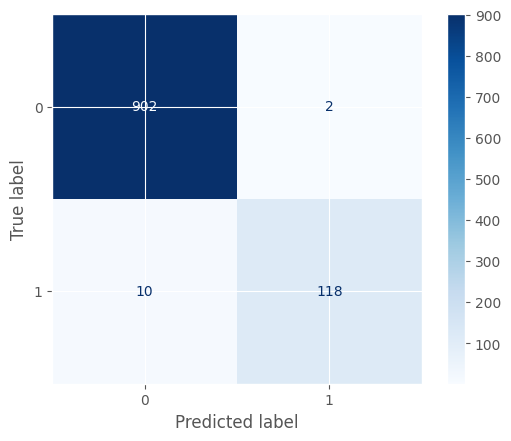

In [280]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap= "Blues"
)

In [283]:
emails = [
    "Congratulations! You Won a free iPhone. Click here now.",

    "Hey, are we still meeting tomorrow at 10 AM?",

    "URGENT! Claim your $1000 Walmart gift card today."
]

emails_vectorize = tfidf.transform(emails)

predictions = best_model.predict(emails_vectorize)

for email, prediction in zip(emails, predictions):
    label = "Spam" if prediction == 1 else "Ham"

    print(label, ":", email)

Spam : Congratulations! You Won a free iPhone. Click here now.
Ham : Hey, are we still meeting tomorrow at 10 AM?
Spam : URGENT! Claim your $1000 Walmart gift card today.


In [284]:
import pickle

with open("SpamOrNot.pkl", "wb") as file:
    pickle.dump(best_model, file)
    

In [286]:
with open("TfidfVectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Done!")

Done!


In [288]:
with open("SpamOrNot.pkl", "rb") as file:

    loaded_model = pickle.load(file)

with open("TfidfVectorizer.pkl", "rb") as file:

    loaded_vectorizer = pickle.load(file)

In [290]:
email = [

    "Congrats! You have won $1000. Click here to claim."
]

emails_vector = loaded_vectorizer.transform(email)

prediction = loaded_model.predict(emails_vector)[0]

In [291]:
print("Spam" if prediction == 1 else "Ham")

Spam
